In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [29]:

trainperf = pd.read_csv("../data/trainperf.csv")
trainperf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good


In [30]:
customer_prevcleaned = pd.read_csv("../data/customer_prevcleaned.csv")
customer_prevcleaned.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,previous_default,days_overdue
0,8a1088a0484472eb01484669e3ce4e0b,301960241,1,2017-07-02 19:19:01,2017-07-02 18:17:53,11500.0,15,2017-07-24 20:50:43,NaN,2017-07-18,2017-07-24 20:40:34,0,6
1,8a1a1e7e4f707f8b014f797718316cad,301947045,4,2017-06-21 22:09:51,2017-06-21 21:09:44,39000.0,60,2017-07-26 19:48:11,NaN,2017-07-21,2017-07-20 15:05:33,0,5
2,8a1a32fc49b632520149c3b8fdf85139,301937031,7,2017-06-13 11:02:36,2017-06-13 10:01:27,24500.0,30,2017-07-13 18:45:26,NaN,2017-07-13,2017-07-13 18:35:18,0,2
3,8a1eb5ba49a682300149c3c068b806c7,301916041,8,2017-05-23 08:25:46,2017-05-23 07:24:38,39000.0,60,2017-07-12 13:02:44,NaN,2017-06-22,2017-06-30 21:03:22,0,20
4,8a1edbf14734127f0147356fdb1b1eb2,301927936,2,2017-06-05 17:01:03,2017-06-05 16:00:57,13000.0,30,2017-06-27 18:13:52,NaN,2017-07-05,2017-06-27 18:03:43,0,0


In [31]:
traindemographics = pd.read_csv("../data/traindemographics.csv")
traindemographics.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


In [32]:
# Check duplicates in customer_prevcleaned
print("Duplicate customer IDs in customer_prevcleaned:",
      customer_prevcleaned["customerid"].duplicated().sum())

# Check duplicates in trainperf
print("Duplicate customer IDs in trainperf:",
      trainperf["customerid"].duplicated().sum())

# Check duplicates in demographics
print("Duplicate customer IDs in demographics:",
      traindemographics["customerid"].duplicated().sum())


Duplicate customer IDs in customer_prevcleaned: 0
Duplicate customer IDs in trainperf: 0
Duplicate customer IDs in demographics: 12


In [33]:
# printing duplicates
duplicate_demo = (
    traindemographics[
        traindemographics.duplicated("customerid", keep=False)
    ]
    .sort_values("customerid")
)

duplicate_demo

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
1414,8a858e625c8d993a015c938f829f77ee,1988-12-20 00:00:00.000000,Savings,5.768333,5.561992,First Bank,NaN,Permanent,NaN
1928,8a858e625c8d993a015c938f829f77ee,1988-12-20 00:00:00.000000,Savings,5.768333,5.561992,First Bank,NaN,Permanent,NaN
445,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30 00:00:00.000000,Savings,3.367008,6.497313,Sterling Bank,NaN,Permanent,NaN
1090,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30 00:00:00.000000,Savings,3.367008,6.497313,Sterling Bank,NaN,Permanent,NaN
1996,8a858ec65cc6352b015cc64525ea0763,1985-01-30 00:00:00.000000,Savings,3.845728,7.411737,GT Bank,NaN,Permanent,NaN
1520,8a858ec65cc6352b015cc64525ea0763,1985-01-30 00:00:00.000000,Savings,3.845728,7.411737,GT Bank,NaN,Permanent,NaN
272,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
517,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
4126,8a858f1e5baffcc9015bb02b505f180d,1983-04-06 00:00:00.000000,Savings,6.969350,4.818535,GT Bank,NaN,Permanent,NaN
3021,8a858f1e5baffcc9015bb02b505f180d,1983-04-06 00:00:00.000000,Savings,6.969350,4.818535,GT Bank,NaN,Permanent,NaN


In [34]:
#duplicates are unique, keep only first occurence
traindemographics = traindemographics.drop_duplicates(
    subset="customerid",
    keep="first"
)


print(
    traindemographics["customerid"].duplicated().sum()
)

0


In [35]:
#rename loan number in customer historical data as number of previous loans 

customer_prevcleaned.rename(
    columns={"loannumber":"no_of_previous_loans"},
    inplace=True
)


#rename laon number in customers current-loan data to current loan number. 
trainperf  = trainperf .rename(
    columns={"loannumber": "current_loan_number"}
)

In [36]:
# Merge customer prevcleaned into trainperf on customer id criteria, adding only no_of_previous_loans, previous default & days overdue
trainperf_merged = trainperf.merge(
    customer_prevcleaned[
        ["customerid",
         "previous_default",
         "no_of_previous_loans",
         "days_overdue"]
    ],
    on="customerid",
    how="left"
)


trainperf_merged.head()

,customerid,systemloanid,current_loan_number,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,previous_default,no_of_previous_loans,days_overdue
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,0.0,11.0,39.0
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good,0.0,6.0,30.0
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good,0.0,2.0,11.0
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good,0.0,8.0,0.0


In [37]:
#merge traindemographics into trainperf merged

trainperf_merged = trainperf_merged.merge(
    traindemographics[
        [
            "customerid",
            "birthdate",
            "bank_account_type"
        ]
    ],
    on="customerid",
    how="left"
)

#convert birthdate to datetime
trainperf_merged["birthdate"] = pd.to_datetime(
    trainperf_merged["birthdate"]
)


# Calculate customer's age(yr) from birthdate
today = pd.Timestamp.today()

trainperf_merged["age"] = (
    (today - trainperf_merged["birthdate"]).dt.days
    // 365
)


trainperf_merged.head()

,customerid,systemloanid,current_loan_number,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,previous_default,no_of_previous_loans,days_overdue,birthdate,bank_account_type,age
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good,0.0,11.0,39.0,1972-01-15,Other,54.0
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good,NaN,NaN,NaN,1985-08-23,Savings,40.0
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good,0.0,6.0,30.0,1984-09-18,Other,41.0
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good,0.0,2.0,11.0,1977-10-10,Savings,48.0
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good,0.0,8.0,0.0,1986-09-07,Other,39.0


In [38]:
# Rename the target column from good-bad-flag to default
trainperf_merged = trainperf_merged.rename(
    columns={"good_bad_flag": "default"}
)

# Rename the target classes 
trainperf_merged["default"] = trainperf_merged["default"].replace({
    "Good": "No Default",
    "Bad": "Default"
})


# Convert date columns to datetime
date_columns = ["approveddate", "creationdate"]
trainperf_merged[date_columns] = trainperf_merged[date_columns].apply(pd.to_datetime)


# drop  columns
trainperf_merged.drop(columns=['birthdate', 'referredby', 'systemloanid'], inplace=True)
                      
trainperf_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customerid            4368 non-null   object        
 1   current_loan_number   4368 non-null   int64         
 2   approveddate          4368 non-null   datetime64[ns]
 3   creationdate          4368 non-null   datetime64[ns]
 4   loanamount            4368 non-null   float64       
 5   totaldue              4368 non-null   float64       
 6   termdays              4368 non-null   int64         
 7   default               4368 non-null   object        
 8   previous_default      4359 non-null   float64       
 9   no_of_previous_loans  4359 non-null   float64       
 10  days_overdue          4359 non-null   float64       
 11  bank_account_type     3269 non-null   object        
 12  age                   3269 non-null   float64       
dtypes: datetime64[ns](

In [39]:
#summary of missing values
#the backslash n tells python to skip a line,
print("\n\nSUMMARY OF MISSING VALUES")
print(trainperf_merged.isnull().sum())

trainperf_merged.shape



SUMMARY OF MISSING VALUES
customerid                 0
current_loan_number        0
approveddate               0
creationdate               0
loanamount                 0
totaldue                   0
termdays                   0
default                    0
previous_default           9
no_of_previous_loans       9
days_overdue               9
bank_account_type       1099
age                     1099
dtype: int64


(4368, 13)

In [40]:
# filling missing values for non categorical values
for col in ['previous_default', 'no_of_previous_loans', 'days_overdue', 'age']:
    trainperf_merged[col] = trainperf_merged[col].fillna(0)

# filling NAN in bank_account_type with "None"
trainperf_merged["bank_account_type"] = trainperf_merged["bank_account_type"].fillna("None")


print(trainperf_merged.isnull().sum())

customerid              0
current_loan_number     0
approveddate            0
creationdate            0
loanamount              0
totaldue                0
termdays                0
default                 0
previous_default        0
no_of_previous_loans    0
days_overdue            0
bank_account_type       0
age                     0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

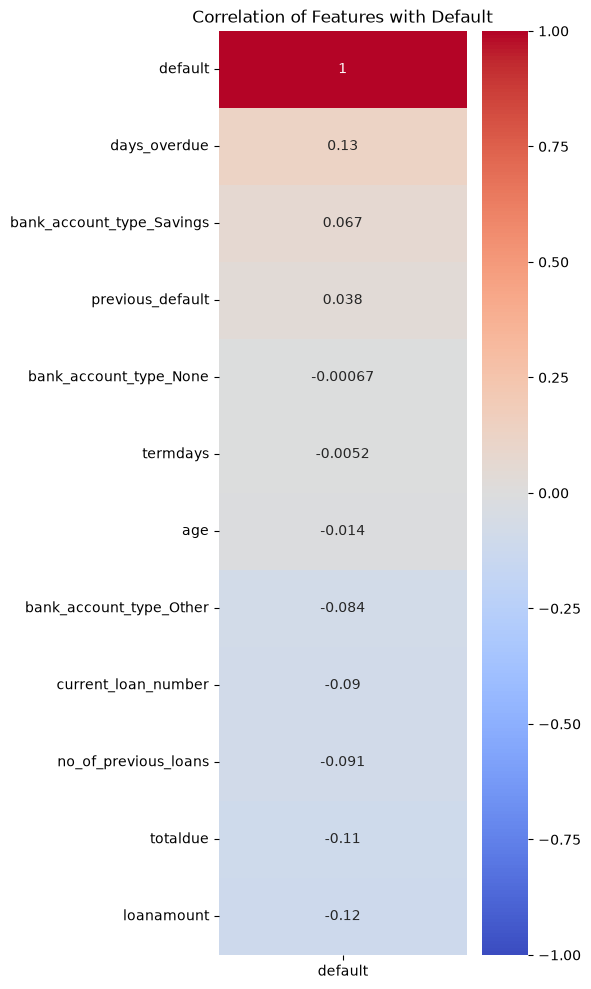

In [41]:
#one-hot encdoding for bank account type column
trainperf_merged = pd.get_dummies(trainperf_merged, columns=['bank_account_type'], drop_first = True,)

#convert the boolean values in bank account type columns to integers (0 and 1. false & true)
trainperf_merged = trainperf_merged.astype({col: int for col in trainperf_merged.columns if col.startswith("bank_account_type_")})

# instead of using label encoder that arranges the classes in alphabetical order BY-DEFAULT, use map which allows control over which class is 0 & 1
trainperf_merged["default"] = trainperf_merged["default"].map({
    "No Default": 0,
    "Default": 1
})


#compute correlation matrix only for numerical columns
correlation_matrix = trainperf_merged.corr(numeric_only=True)

#focus on correlation  with default
default_correlation = correlation_matrix[["default"]].sort_values(by="default", ascending=False)

plt.figure(figsize=(4, 12))
sns.heatmap(default_correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Features with Default")
plt.show

The distance from zero describes the strength of the relationship.Closer to ±1 → stronger relationship. Closer to 0 → weaker relationship.

Positive Correlation (+): As the feature increases, the default also tends to increase.
Business interpretation: The lender should pay closer attention to customers with higher values of that feature because they are more likely to default.

days_overdue (0.13): This has the strongest positive correlation with default.
Customers who were more overdue on their previous loans are more likely to default again, as customers who struggled to repay previous loans may struggle again.

previous_default (0.038): +ve but very weak, customers who have defaulted before are more likely to default again.  Reasons for the weak relationship could be that the  dataset contains few previous defaulters


Negative Correlation (-): As the feature increases, the default tends to decrease. Customers with higher values of that feature are less likely to default.

loanamount (-0.12): This shows the strongest -ve relationship.
Business interpretation: Customers receiving larger loans appear less likely to default.
This does not mean larger loans reduce default risk, it implies that lenders reserve larger loans for customers with stronger credit histories/better repayment behaviour.

totaldue (-0.11): Customers with larger total repayment amounts appear less likely to default. this implies that lenders may approve larger loans for customers they already consider to be lower risk.

no_of_previous_loans (-0.091): Customers with more completed previous loans are less likely to default.

In [42]:
# there is a class imbalance in the target variable, with more instances of "No Default" than "Default". 
trainperf_merged['default'].value_counts()

default
0    3416
1     952
Name: count, dtype: int64

              precision    recall  f1-score   support

           0      0.862     0.440     0.583       684
           1      0.270     0.747     0.397       190

    accuracy                          0.507       874
   macro avg      0.566     0.594     0.490       874
weighted avg      0.734     0.507     0.542       874

confusion_matrix: [[301 383]
 [ 48 142]]
accuracy_score: 0.5068649885583524


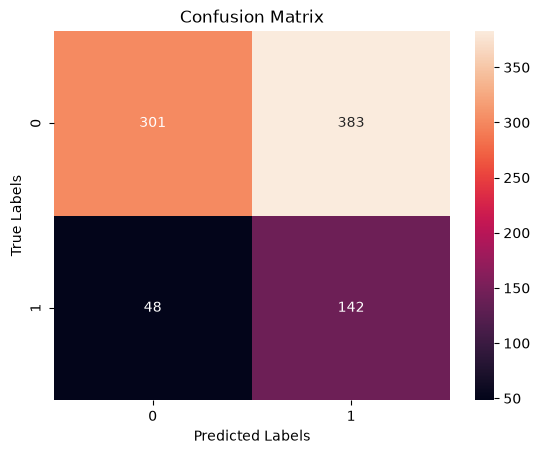

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
import pandas as pd
import time

# assign features and target
y = trainperf_merged["default"]

# Define the feature matrix
X = trainperf_merged.drop(columns=["default", "customerid", "approveddate", "creationdate"])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

THRESHOLD = 0.3 #lower than 0.5 to boost recall


uyai = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)
uyai.fit(X_train, y_train)

probabilities = uyai.predict_proba(X_test)[:, 1]
y_pred = (probabilities >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred, digits=3))
print(f'confusion_matrix: {confusion_matrix(y_test, y_pred)}')
print(f'accuracy_score: {accuracy_score(y_test, y_pred)}')


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,  fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

probabilities = uyai.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.262   0.774   0.391   
0.3     0.270   0.747   0.397   
0.35    0.284   0.663   0.398   
0.4     0.288   0.600   0.389   
0.45    0.290   0.542   0.378   
0.5     0.350   0.432   0.387   


In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.82 seconds
⏱ Prediction time: 0.0183 seconds
              precision    recall  f1-score   support

           0      0.871     0.444     0.589       684
           1      0.276     0.763     0.406       190

    accuracy                          0.514       874
   macro avg      0.574     0.604     0.497       874
weighted avg      0.742     0.514     0.549       874



In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

probabilities = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.262   0.795   0.394   
0.3     0.276   0.763   0.406   
0.35    0.291   0.679   0.408   
0.4     0.295   0.616   0.399   
0.45    0.303   0.547   0.390   
0.5     0.323   0.442   0.373   


⏱ Training time: 0.08 seconds
⏱ Prediction time: 0.0000 seconds
Classification_report:               precision    recall  f1-score   support

           0       0.90      0.26      0.41       684
           1       0.25      0.89      0.39       190

    accuracy                           0.40       874
   macro avg       0.58      0.58      0.40       874
weighted avg       0.76      0.40      0.41       874

confusion_matrix: [[181 503]
 [ 20 170]]
accuracy_score: 0.40160183066361554


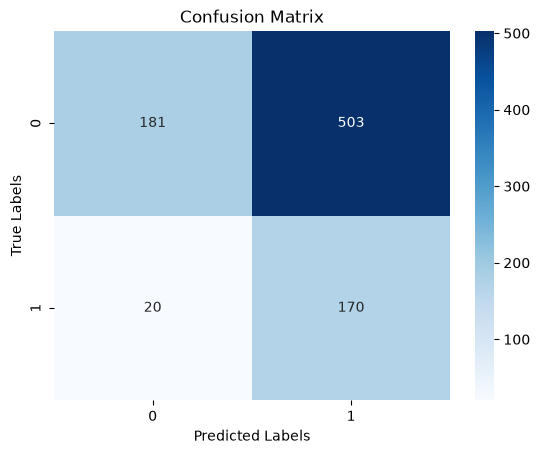

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
import time

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

threshold_04 = 0.40

# Create the Logistic Regression model
logistic = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)



from src.model.risk_scoring import calculate_risk_score


# Start training timer
start_train = time.time()

# Train the model
logistic.fit(X_train_scaled, y_train)

# Stop training timer
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Start prediction timer
start_pred = time.time()

# Probability that each customer belongs to the default class
probabilities = logistic.predict_proba(X_test_scaled)[:, 1]

# calculate risk score and risk category for each customer based on probability of default
risk_results = pd.DataFrame({"default_probability": probabilities})
risk_results[["risk_score", "risk_category"]] = risk_results["default_probability"].apply(lambda x: pd.Series(calculate_risk_score(x)))

# Apply the custom threshold
y_pred_04 = (probabilities >= threshold_04).astype(int)

# readable model decision
risk_results["model_decision"] = np.where(y_pred_04 == 1, "Default", "No Default")

# Stop prediction timer
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

#classification report
print(f'Classification_report: {classification_report(y_test, y_pred_04)}')
print(f'confusion_matrix: {confusion_matrix(y_test, y_pred_04)}')
print(f'accuracy_score: {accuracy_score(y_test, y_pred_04)}')



sns.heatmap(confusion_matrix(y_test, y_pred_04), annot=True,  fmt='d', cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [51]:
risk_results.head(10)

,default_probability,risk_score,risk_category,model_decision
0,0.462986,53.701385,High Risk,Default
1,0.532974,46.702614,High Risk,Default
2,0.545779,45.422146,High Risk,Default
3,0.316250,68.375029,Medium Risk,No Default
4,0.473083,52.691674,High Risk,Default
5,0.454866,54.513360,High Risk,Default
6,0.527033,47.296698,High Risk,Default
7,0.633635,36.636488,High Risk,Default
8,0.329308,67.069245,Medium Risk,No Default
9,0.408636,59.136422,High Risk,Default


In [48]:
#logistic regression threshold tuning
from sklearn.metrics import precision_score, recall_score, f1_score

probabilities = logistic.predict_proba(X_test_scaled)[:, 1]

print("Threshold tuning for Logistic Regression")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probabilities >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    acc = accuracy_score(y_test, preds)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}{acc:<8.3f}")

Threshold tuning for Logistic Regression
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.229   0.984   0.372   0.277   
0.3     0.232   0.974   0.374   0.293   
0.35    0.245   0.937   0.388   0.357   
0.4     0.253   0.895   0.394   0.402   
0.45    0.278   0.821   0.415   0.497   
0.5     0.319   0.626   0.423   0.628   


In [ ]:
import mlflow
import mlflow.sklearn
import time
import joblib
from sklearn.metrics import (classification_report, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score)


# Force MLflow to always use the project root's mlruns folder
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Loan Default Prediction - Logistic Regression")

# Close any previously active MLflow run
mlflow.end_run()
# Start experiment
with mlflow.start_run():

    #Log model parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("threshold", threshold_04)
    

    # training timer
    start_train = time.time()
    logistic.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    #prediction timer
    start_pred = time.time()
    probabilities = logistic.predict_proba(X_test_scaled)[:, 1]
    y_pred_04 = (probabilities >= threshold_04).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # metrics
    precision = precision_score(y_test, y_pred_04)
    recall = recall_score(y_test, y_pred_04)
    f1 = f1_score(y_test, y_pred_04)
    accuracy = accuracy_score(y_test, y_pred_04)
    roc_auc = roc_auc_score(y_test, probabilities)
    #save metrics
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("roc_auc", roc_auc)


    # Save with Joblib
    
    joblib.dump(logistic, "../models/logistic_model.pkl")
    joblib.dump(scaler, "../models/scaler.pkl")

    # Log model to MLflow
    mlflow.sklearn.log_model(logistic, artifact_path="model")

    # Save classification report as an artifact
    report = classification_report(y_test, y_pred_04, digits=3)

    with open("classification_report.txt", "w") as f:
        f.write(report)

    mlflow.log_artifact("classification_report.txt")


# Print evaluation
print(classification_report(y_test, y_pred_04, digits=3))


2026/08/10 06:13:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.900     0.265     0.409       684
           1      0.253     0.895     0.394       190

    accuracy                          0.402       874
   macro avg      0.577     0.580     0.402       874
weighted avg      0.760     0.402     0.406       874



In [50]:
import sys
from pathlib import Path

# Project root
project_root = Path.cwd().parent

# Add the folder containing data_quality.py
data_quality_path = project_root / "src" / "data" / "great_expectation"

sys.path.insert(0, str(data_quality_path))

# Import the validation function
from data_quality import validate_loan_data

# Run Great Expectations validation
validation_passed, failed_checks = validate_loan_data(
    trainperf_merged
)

print("Validation passed:", validation_passed)
print("Failed checks:", failed_checks)

🔍 Starting data validation with Great Expectations...
   📋 Validating schema and required columns...
   💼 Validating business logic constraints...
   📊 Validating numeric ranges...
   🧹 Validating missing values...
   🔄 Validating data consistency...
   ⚙️ Running complete validation suite...
✅ Data validation PASSED: 31/31 checks successful
Validation passed: True
Failed checks: []


In [53]:

# LOGISTIC REGRESSION FEATURE COEFFICIENTS


# Get the feature names used by the model
feature_names = X_train.columns

# Extract the coefficients for class 1 (Default)
coefficients = logistic.coef_[0]

# Create a DataFrame linking features to coefficients
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Calculate absolute coefficient magnitude
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

# Sort by importance
coef_df = coef_df.sort_values(
    by="absolute_coefficient",
    ascending=False
)

print("Logistic Regression Feature Coefficients:")
display(coef_df)

Logistic Regression Feature Coefficients:


,feature,coefficient,absolute_coefficient
1,loanamount,-0.761879,0.761879
6,days_overdue,0.653013,0.653013
2,totaldue,0.437585,0.437585
10,bank_account_type_Savings,0.423540,0.423540
4,previous_default,-0.259128,0.259128
7,age,-0.242312,0.242312
5,no_of_previous_loans,-0.237474,0.237474
3,termdays,0.156553,0.156553
0,current_loan_number,0.136253,0.136253
9,bank_account_type_Other,0.061807,0.061807


In [54]:
coef_df["direction"] = np.where(
    coef_df["coefficient"] > 0,
    "Increases Default Risk",
    "Decreases Default Risk"
)

print("Ranked Logistic Regression Key Factors:")
display(
    coef_df[
        ["feature", "coefficient", "absolute_coefficient", "direction"]
    ]
)

Ranked Logistic Regression Key Factors:


,feature,coefficient,absolute_coefficient,direction
1,loanamount,-0.761879,0.761879,Decreases Default Risk
6,days_overdue,0.653013,0.653013,Increases Default Risk
2,totaldue,0.437585,0.437585,Increases Default Risk
10,bank_account_type_Savings,0.423540,0.423540,Increases Default Risk
4,previous_default,-0.259128,0.259128,Decreases Default Risk
7,age,-0.242312,0.242312,Decreases Default Risk
5,no_of_previous_loans,-0.237474,0.237474,Decreases Default Risk
3,termdays,0.156553,0.156553,Increases Default Risk
0,current_loan_number,0.136253,0.136253,Increases Default Risk
9,bank_account_type_Other,0.061807,0.061807,Increases Default Risk


In [ ]:

# FEATURE-TO-FEATURE CORRELATION MATRIX
# Checking multicollinearity among predictors


# Calculate correlations between all predictor variables
feature_correlation = X.corr()

print("Feature-to-feature correlation matrix:")
display(feature_correlation)

Feature-to-feature correlation matrix:


,current_loan_number,loanamount,totaldue,termdays,previous_default,no_of_previous_loans,days_overdue,age,bank_account_type_None,bank_account_type_Other,bank_account_type_Savings
current_loan_number,1.000000,0.833318,0.815303,0.405131,0.028252,0.999624,0.313737,0.006086,-0.008153,0.441209,-0.307791
loanamount,0.833318,1.000000,0.994392,0.558818,-0.019757,0.832906,0.187733,0.007625,-0.004524,0.371284,-0.260085
totaldue,0.815303,0.994392,1.000000,0.627599,-0.019128,0.814924,0.192136,0.008131,-0.004288,0.364176,-0.254978
termdays,0.405131,0.558818,0.627599,1.000000,-0.000782,0.404612,0.195713,-0.002944,0.001440,0.210113,-0.148820
previous_default,0.028252,-0.019757,-0.019128,-0.000782,1.000000,0.028308,0.594740,-0.012849,0.014598,0.025352,-0.029903
no_of_previous_loans,0.999624,0.832906,0.814924,0.404612,0.028308,1.000000,0.314053,0.006526,-0.008795,0.441111,-0.307180
days_overdue,0.313737,0.187733,0.192136,0.195713,0.594740,0.314053,1.000000,-0.002163,-0.012366,0.233818,-0.155985
age,0.006086,0.007625,0.008131,-0.002944,-0.012849,0.006526,-0.002163,1.000000,-0.959157,0.232699,0.660690
bank_account_type_None,-0.008153,-0.004524,-0.004288,0.001440,0.014598,-0.008795,-0.012366,-0.959157,1.000000,-0.243091,-0.693207
bank_account_type_Other,0.441209,0.371284,0.364176,0.210113,0.025352,0.441111,0.233818,0.232699,-0.243091,1.000000,-0.501244


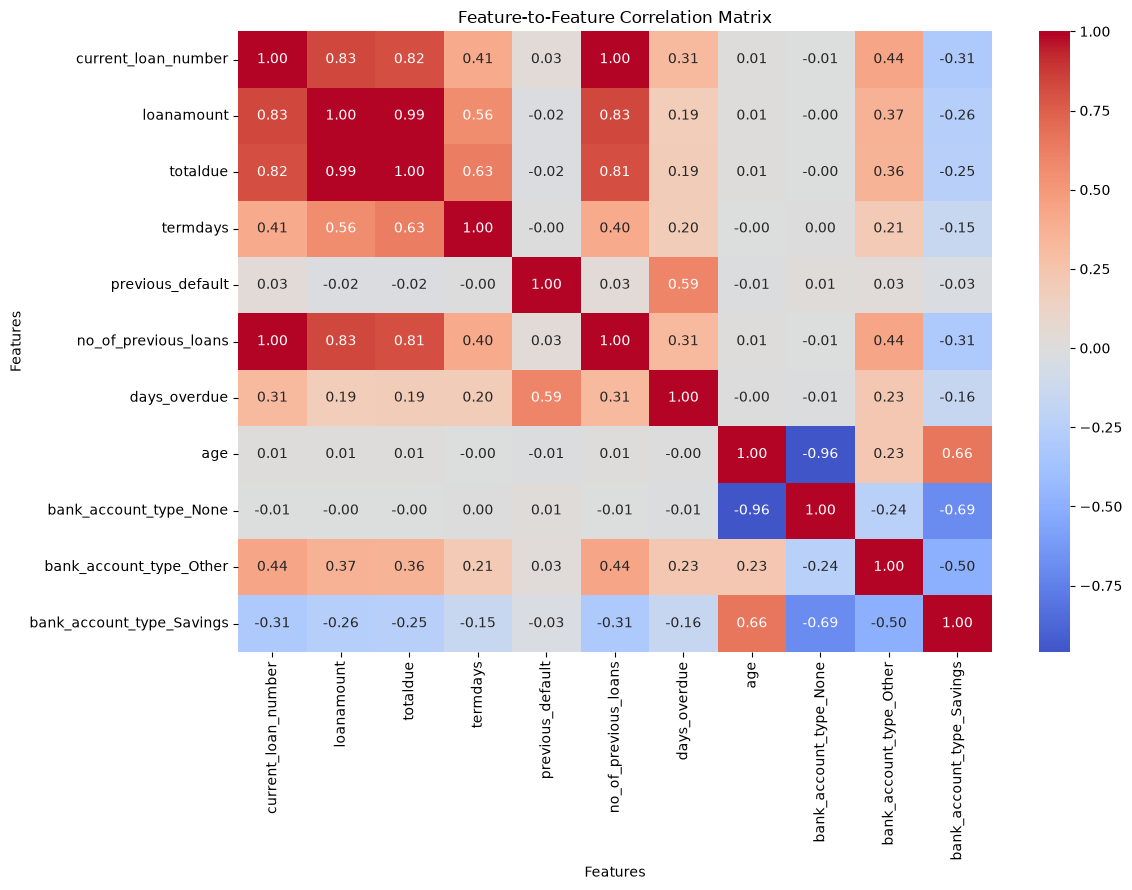

In [ ]:

# VISUALIZE FEATURE-TO-FEATURE CORRELATIONS


plt.figure(figsize=(12, 9))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature-to-Feature Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()